In [1]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from evl.vision_transformer import VisionTransformer2D
from evl.model import EVLTransformer
from collections import OrderedDict
import os
from tqdm import tqdm
import clip


In [2]:
def count_files(directory):
    file_count = 0
    # Walk through all directories and files in the specified directory
    for root, dirs, files in os.walk(directory):
        file_count += len(files)
    return file_count

# Replace 'your_directory_path' with the path to the directory you want to check
directory_path = '/net/polaris/storage/deeplearning/ntu/nturgb+d_depth_masked/'
print(f"Number of files in '{directory_path}': {count_files(directory_path)}")

Number of files in '/net/polaris/storage/deeplearning/ntu/nturgb+d_depth_masked/': 4807016


In [4]:
def count_directories(directory):
    # List all entries in the directory and count only directories
    return len([entry for entry in os.listdir(directory) if os.path.isdir(os.path.join(directory, entry))])

# Replace 'your_directory_path' with the path to the directory you want to check
directory_path = '/net/polaris/storage/deeplearning/ntu/nturgb+d_depth_masked/'
print(f"Number of directories in '{directory_path}': {count_directories(directory_path)}")

Number of directories in '/net/polaris/storage/deeplearning/ntu/nturgb+d_depth_masked/': 56880


In [12]:
def count_files(directory):
    file_count = 0
    # Walk through all directories and files in the specified directory
    for root, dirs, files in os.walk(directory):
        file_count += len(files)
    return file_count

# Replace 'your_directory_path' with the path to the directory you want to check
directory_path = '/net/polaris/storage/deeplearning/ntu/nturgb+d_skeletons_npy/'
print(f"Number of files in '{directory_path}': {count_files(directory_path)}")

Number of files in '/net/polaris/storage/deeplearning/ntu/nturgb+d_skeletons_npy/': 56880


In [3]:
def load_model_from_checkpoint(model, checkpoint_path):
    """
    Loads a model's state dictionary from a checkpoint without the "module." prefix.
    
    Parameters:
    - model (torch.nn.Module): The model to which the state dictionary will be loaded.
    - checkpoint_path (str): Path to the checkpoint file.

    Returns:
    - model (torch.nn.Module): The model with its state dictionary loaded from the checkpoint.
    """

    # Load the checkpoint
    ckpt = torch.load(checkpoint_path)

    # Create a new state dictionary without the "module." prefix
    new_state_dict = OrderedDict()
    for key, value in ckpt['model'].items():
        name = key[7:]  # remove the "module." prefix
        new_state_dict[name] = value

    # Load the state dictionary into the model
    model.load_state_dict(new_state_dict)

    return model

In [4]:
class CLIPModelx(nn.Module):
    def __init__(self):
        super(CLIPModelx, self).__init__()
        self.rgb_model = EVLTransformer(backbone_path='/home/bas06400/.cache/clip/ViT-B-16.pt')
        self.ir_model = EVLTransformer(backbone_path='/home/bas06400/.cache/clip/ViT-B-16.pt')
        checkpoint_path = '/home/bas06400/schlaf/k400_vitb16_8f_dec4x768.pth'
        self.rgb_model = load_model_from_checkpoint(self.rgb_model,checkpoint_path)
        load_model_from_checkpoint(self.ir_model,checkpoint_path)

        # Projection layers to transform 400D embeddings to 512D
        self.rgb_projection = nn.Linear(400, 512)
        self.ir_projection = nn.Linear(400, 512)


    def forward(self, image, text):
        
        # Get 400D embeddings from RGB and IR models
        rgb_features_400D = self.rgb_model(image)
        ir_features_400D = self.ir_model(text)
        
        # Project the 400D embeddings to 512D
        rgb_features = self.rgb_projection(rgb_features_400D)
        ir_features = self.ir_projection(ir_features_400D)
        return rgb_features, ir_features

model = CLIPModelx()
model

CLIPModelx(
  (rgb_model): EVLTransformer(
    (decoder): EVLDecoder(
      (decoder_layers): ModuleList(
        (0-3): 4 x TransformerDecoderLayer(
          (attn): Attention(
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (mlp): Sequential(
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (act): QuickGELU()
            (dropout): Dropout(p=0.5, inplace=False)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (norm3): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )

In [7]:


def generate_list_file(data_root, output_file):
    # List all files for each modality
    modalities = ['nturgb+d_rgb', 'nturgb+d_ir']
    modality_files = {modality: sorted(os.listdir(os.path.join(data_root, modality))) for modality in modalities}
    
    with open(output_file, 'w') as f:
        # Iterate over files in the RGB modality as a reference
        for rgb_file in modality_files['nturgb+d_rgb']:
            # Extract the prefix from the RGB file name
            prefix = rgb_file.rsplit('_', 1)[0]
            
            # Find corresponding files in other modalities
            paths = [os.path.join(modality, prefix + '_' + modality.split('_')[-1] + '.avi') for modality in modalities]
            
            # Extract the action label from the filename
            action_label = rgb_file.split('A')[-1].split('_')[0]
            
            # Write to the file
            f.write(' '.join(paths) + ' ' + action_label + '\n')

data_root = "/home/bas06400/ntu"
output_file = "rgb_ir_depth_dataset.txt"
generate_list_file(data_root, output_file)

In [11]:
def generate_list_file(data_root, output_file):
    # List all files for each modality
    modalities = ['nturgb+d_rgb', 'nturgb+d_ir']
    modality_files = {modality: sorted(os.listdir(os.path.join(data_root, modality))) for modality in modalities}
    
    # List all subfolders for the depth modality
    depth_folders = sorted(os.listdir(os.path.join(data_root, 'nturgb+d_depth_masked')))
    
    with open(output_file, 'w') as f:
        # Iterate over files in the RGB modality as a reference
        for rgb_file in modality_files['nturgb+d_rgb']:
            # Extract the prefix from the RGB file name
            prefix = rgb_file.rsplit('_', 1)[0]
            
            # Find corresponding files in other modalities
            paths = [os.path.join(modality, prefix + '_' + modality.split('_')[-1] + '.avi') for modality in modalities]

            # Construct the depth folder path directly using the same prefix
            depth_folder_path = os.path.join('nturgb+d_depth_masked', prefix)
            
            # Construct the skeleton data path
            skeleton_data_path = os.path.join('nturgb+d_skeleton', prefix + '.skeleton.npy')
            
            # Extract the action label from the filename
            action_label = rgb_file.split('A')[-1].split('_')[0]
            
            # Write RGB, IR, depth, and skeleton paths to the file
            f.write(' '.join(paths + [depth_folder_path, skeleton_data_path]) + ' ' + action_label + '\n')

data_root = "/net/polaris/storage/deeplearning/ntu"
output_file = "rgb_ir_depth_skeleton_dataset.txt"
generate_list_file(data_root, output_file)

In [2]:
from multimodal_dataset import MultiModalVideoDataset
from torch.utils.data import random_split

data_root = '/net/polaris/storage/deeplearning/ntu'
data_list = '/home/bas06400/Thesis/rgb_ir_depth_skeleton_dataset.txt'
data = MultiModalVideoDataset(data_list, data_root, ['rgb','ir','depth'], use_advanced_processing=False)

print(data[0][0]['rgb'].shape, data[0][0]['ir'].shape, data[0][0]['depth'].shape, data[0][1])

# Calculate lengths of splits
total_len = len(data)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

# Split the dataset
train_data, val_data, test_data = random_split(data, [train_len, val_len, test_len])

"""
for idx in range(len(train_data)):
    x, y ,z = train_data[idx][0]
    del x, y ,z
"""




torch.Size([12, 3, 1080, 1920]) torch.Size([12, 1, 424, 512]) torch.Size([12, 1, 424, 512]) 1


'\nfor idx in range(len(train_data)):\n    x, y ,z = train_data[idx][0]\n    del x, y ,z\n'

Modality: rgb, Total Frames: 12


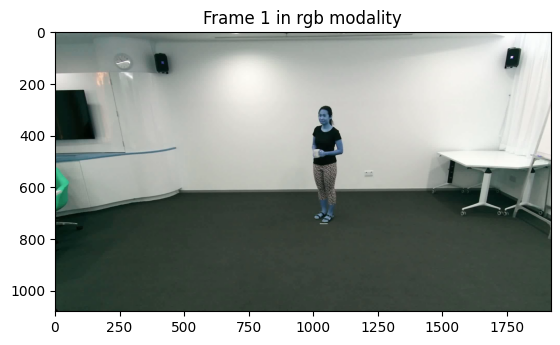

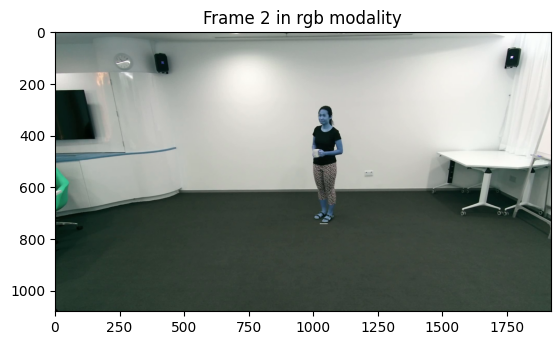

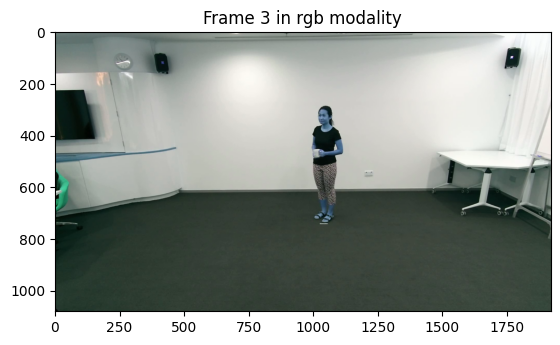

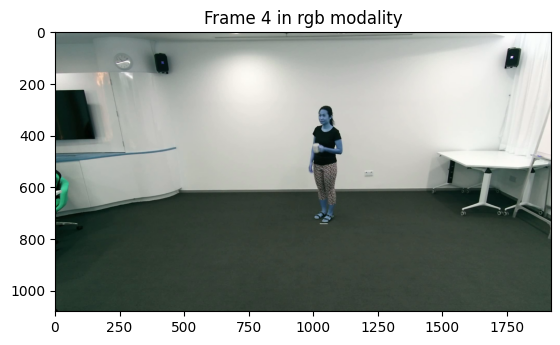

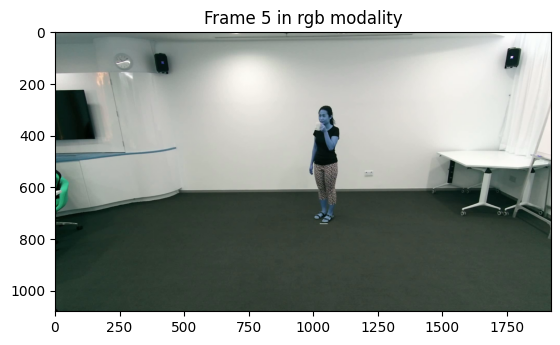

Modality: ir, Total Frames: 12


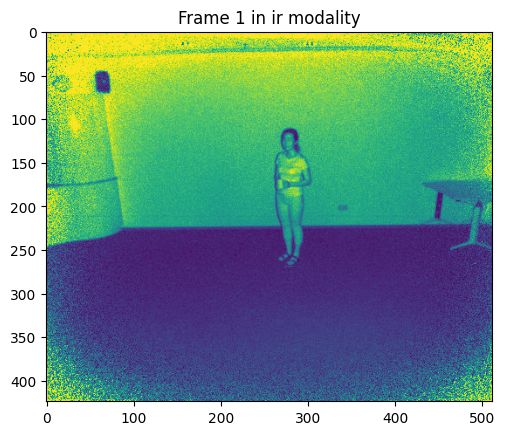

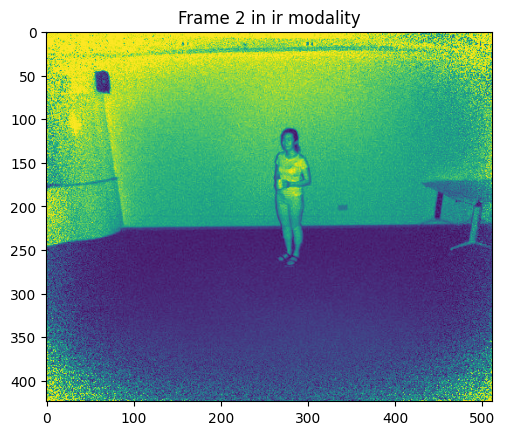

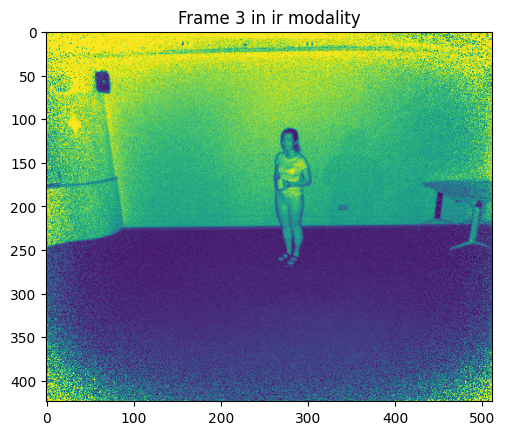

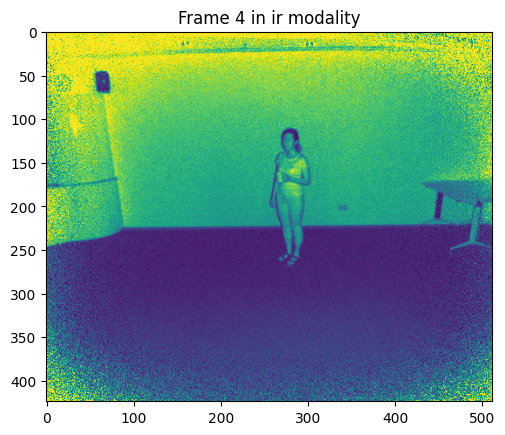

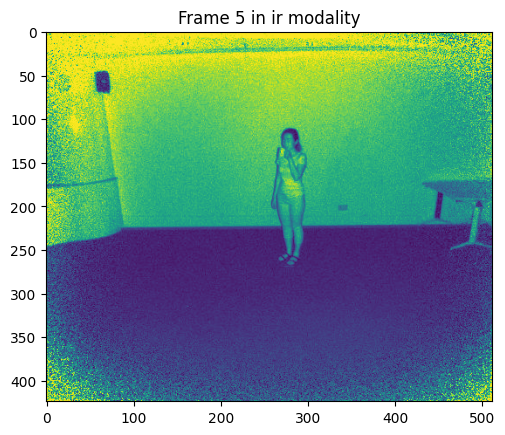

Modality: depth, Total Frames: 12


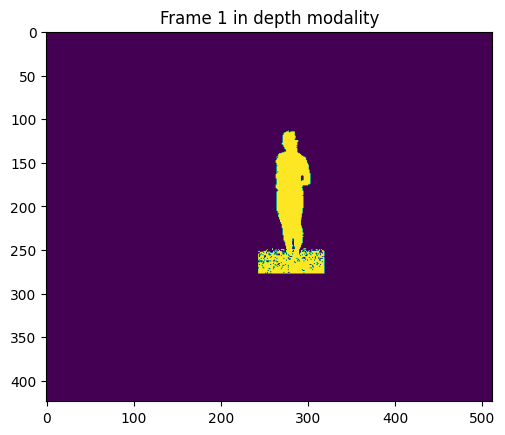

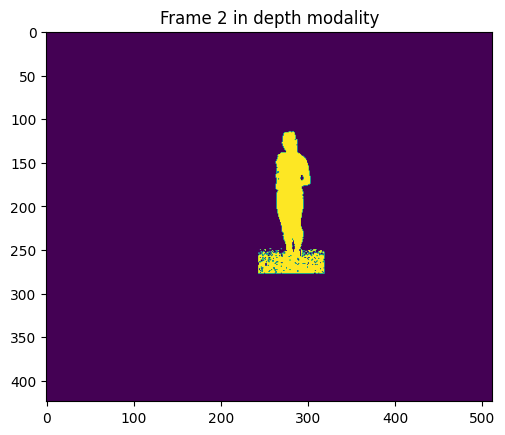

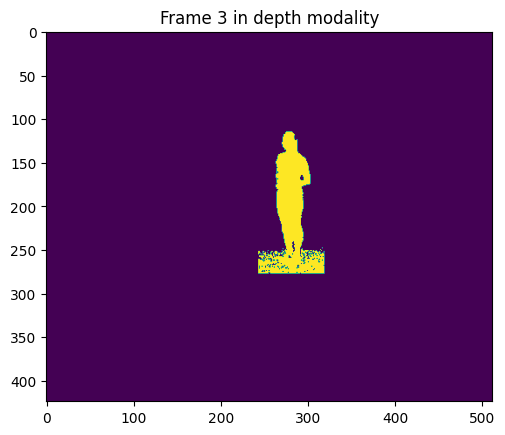

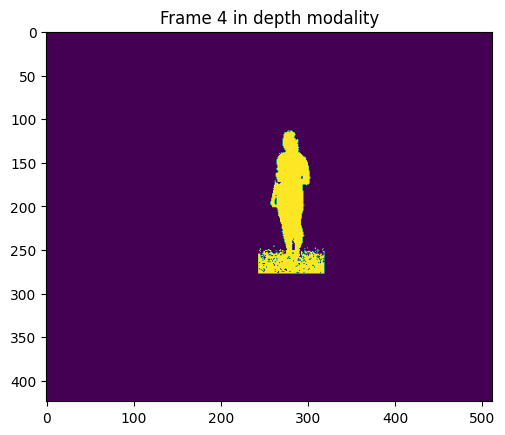

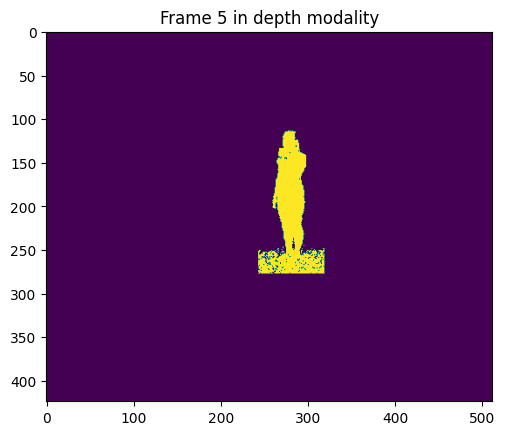

In [3]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Function to convert a tensor to an image
def tensor_to_image(tensor):
    # If the tensor has a channel dimension at the end, move it to the beginning
    if tensor.shape[-1] in [1, 3]:  # Grayscale or RGB
        tensor = tensor.permute(2, 0, 1)
    
    # Convert to PIL Image for easy visualization
    return transforms.ToPILImage()(tensor)

# Select a single sample from the dataset
sample_idx = 0
modality_frames, label = data[sample_idx]

# Iterate through each modality in the sample
for modality in modality_frames:
    frames = modality_frames[modality]
    print(f"Modality: {modality}, Total Frames: {len(frames)}")

    # Display the first few frames in this modality
    for i, frame_tensor in enumerate(frames):
        if i >= 5:  # Limit the number of frames to display
            break

        image = tensor_to_image(frame_tensor)
        plt.imshow(image)
        plt.title(f"Frame {i+1} in {modality} modality")
        plt.show()

In [4]:
# Select a single sample from the dataset
sample_idx = 0
modality_frames, label = data[sample_idx]

# Check the pixel value ranges for each modality
for modality, frames in modality_frames.items():
    min_val, max_val = float('inf'), -float('inf')
    for frame in frames:
        min_val = min(min_val, frame.min().item())
        max_val = max(max_val, frame.max().item())
    
    print(f"Modality: {modality}, Min Pixel Value: {min_val}, Max Pixel Value: {max_val}")

Modality: rgb, Min Pixel Value: 0.0, Max Pixel Value: 1.0
Modality: ir, Min Pixel Value: 0.0, Max Pixel Value: 1.0
Modality: depth, Min Pixel Value: 0.0, Max Pixel Value: 1.0


In [7]:
def custom_collate_fn(batch):
    """
    Custom collate function to handle batches of data from MultiModalVideoDataset.
    
    Args:
    - batch (list): List of samples fetched from `MultiModalVideoDataset`.
    
    Returns:
    - collated_data (dict): Collated data for each modality.
    - collated_labels (tensor): Collated labels.
    """
    collated_data = {}
    collated_labels = []
    
    # Initialize empty lists for each modality in the first sample
    for modality in batch[0][0].keys():
        collated_data[modality] = []
    
    for data, label in batch:
        collated_labels.append(label-1)
        for modality, frames in data.items():
            collated_data[modality].append(frames)
    
    # Convert lists to tensors for each modality
    for modality, frames_list in collated_data.items():
        collated_data[modality] = torch.stack(frames_list)
    
    collated_labels = torch.tensor(collated_labels)
    
    return collated_data, collated_labels

In [9]:
# Create a DataLoader
batch_size = 64
shuffle = True
num_workers = 10
pin_memory = True

# Create a DataLoader for the training set
train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=shuffle,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=custom_collate_fn
)

# Create a DataLoader for the validation set
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,  
    shuffle=False,  
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=custom_collate_fn
)

# Create a DataLoader for the test set
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,  
    shuffle=False,  
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=custom_collate_fn
)
"""
for batch_data, batch_labels in test_loader:
    
    print(batch_data['rgb'].shape)
    break
"""

"\nfor batch_data, batch_labels in test_loader:\n    \n    print(batch_data['rgb'].shape)\n    break\n"

In [9]:
model = model.to('cuda:3')
for batch_data, batch_labels in test_loader:
    x = model(batch_data['rgb'].to('cuda:3'),batch_data['ir'].to('cuda:3'))
    print(x[0].shape, x[0].shape)
    print(batch_labels)
    break


torch.Size([64, 512]) torch.Size([64, 512])
tensor([ 6, 20, 38, 26,  9, 21,  1, 46, 19,  7, 29, 10,  7, 21, 24, 28, 45, 41,
         7, 57, 26, 10, 60, 39, 14, 39, 41, 40, 59, 38, 13, 46, 46, 47, 59,  3,
        41, 58, 55, 39, 45, 42, 38,  5, 45, 20, 36, 39, 52, 28, 54,  3, 44, 21,
         9, 36, 39, 23, 41, 56, 38, 35,  3, 36])


In [13]:
"""
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
learning_rate = 0.001
num_epochs = 50  # Increase the number of epochs since we're trying to overfit
temperature = 0.07  # Temperature parameter for InfoNCE loss

# Initialize the optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# InfoNCE Loss function
def info_nce_loss(emb1, emb2, temperature=0.07):
    sim_matrix = torch.mm(emb1, emb2.t())
    sim_matrix = sim_matrix / temperature
    loss = F.cross_entropy(sim_matrix, torch.arange(sim_matrix.size(0)).to(emb1.device))
    return loss

# Get a single batch from the dataloader
single_batch_data, _ = next(iter(dataloader))
rgb_data_single = single_batch_data['rgb'].to('cuda:3')
ir_data_single = single_batch_data['ir'].to('cuda:3')

# Overfitting on this single batch
for epoch in tqdm(range(num_epochs), desc="Overfitting on single batch"):
    optimizer.zero_grad()

    rgb_emb, ir_emb = model(rgb_data_single, ir_data_single)
    loss = info_nce_loss(rgb_emb, ir_emb, temperature)

    loss.backward()
    optimizer.step()

    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Overfitting test complete!")
"""

'\nimport torch.nn.functional as F\nimport torch.optim as optim\nfrom tqdm import tqdm\n\n# Hyperparameters\nlearning_rate = 0.001\nnum_epochs = 50  # Increase the number of epochs since we\'re trying to overfit\ntemperature = 0.07  # Temperature parameter for InfoNCE loss\n\n# Initialize the optimizer\noptimizer = optim.Adam(model.parameters(), lr=learning_rate)\n\n# InfoNCE Loss function\ndef info_nce_loss(emb1, emb2, temperature=0.07):\n    sim_matrix = torch.mm(emb1, emb2.t())\n    sim_matrix = sim_matrix / temperature\n    loss = F.cross_entropy(sim_matrix, torch.arange(sim_matrix.size(0)).to(emb1.device))\n    return loss\n\n# Get a single batch from the dataloader\nsingle_batch_data, _ = next(iter(dataloader))\nrgb_data_single = single_batch_data[\'rgb\'].to(\'cuda:3\')\nir_data_single = single_batch_data[\'ir\'].to(\'cuda:3\')\n\n# Overfitting on this single batch\nfor epoch in tqdm(range(num_epochs), desc="Overfitting on single batch"):\n    optimizer.zero_grad()\n\n    rgb_em

In [14]:
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
learning_rate = 0.001
num_epochs = 2
temperature = 0.07  # Temperature parameter for InfoNCE loss

# Initialize the optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# InfoNCE Loss function
def info_nce_loss(emb1, emb2, temperature=0.07):
    # Compute similarity matrix
    sim_matrix = torch.mm(emb1, emb2.t())
    # Scale similarity by temperature
    sim_matrix = sim_matrix / temperature
    # Calculate loss
    loss = F.cross_entropy(sim_matrix, torch.arange(sim_matrix.size(0)).to(emb1.device))
    return loss

# Placeholder for best validation loss
best_val_loss = float('inf')

# Training loop
for epoch in range(num_epochs):
    epoch_loss = 0.0
    model.train()
    # Wrap dataloader with tqdm for progress bar
    for batch_data, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        # Move data to GPU
        rgb_data = batch_data['rgb'].to('cuda:3')
        ir_data = batch_data['ir'].to('cuda:3')

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass: Get embeddings or representations from model
        rgb_emb, ir_emb = model(rgb_data, ir_data)

        # Compute the contrastive loss
        loss = info_nce_loss(rgb_emb, ir_emb, temperature)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {epoch_loss / len(train_loader):.4f}")
    # Validation loop
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for batch_data, _ in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{num_epochs}"):
            rgb_data = batch_data['rgb'].to('cuda:3')
            ir_data = batch_data['ir'].to('cuda:3')
            rgb_emb, ir_emb = model(rgb_data, ir_data)
            loss = info_nce_loss(rgb_emb, ir_emb, temperature)
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}")
        
        # Save the best model (optional)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_model.pth')

print("Training complete!")

Epoch 1/2:   0%|          | 0/711 [00:00<?, ?it/s]

Epoch 1/2: 100%|██████████| 711/711 [1:49:13<00:00,  9.22s/it]  


Epoch [1/2], Avg Loss: 22.0246


Validation Epoch 1/2: 100%|██████████| 89/89 [14:35<00:00,  9.84s/it] 


Epoch [1/2], Validation Loss: 0.8957


Epoch 2/2: 100%|██████████| 711/711 [1:53:13<00:00,  9.55s/it]  


Epoch [2/2], Avg Loss: 0.9582


Validation Epoch 2/2: 100%|██████████| 89/89 [15:11<00:00, 10.24s/it] 


Epoch [2/2], Validation Loss: 0.2917
Training complete!


In [12]:

ckpt = torch.load('/home/bas06400/Thesis/best_model.pth')
model.load_state_dict(ckpt)

<All keys matched successfully>

In [10]:
from transformers import CLIPModel, CLIPTokenizer

clip_model_name = "openai/clip-vit-base-patch16"
clip_model = CLIPModel.from_pretrained(clip_model_name).to('cuda:3')
tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)

text_descriptions = [
    "drink water.",
    "eat meal/snack.",
    "brushing teeth.",
    "brushing hair.",
    "drop.",
    "pickup.",
    "throw.",
    "sitting down.",
    "standing up (from sitting position).",
    "clapping.",
    "reading.",
    "writing.",
    "tear up paper.",
    "wear jacket.",
    "take off jacket.",
    "wear a shoe.",
    "take off a shoe.",
    "wear on glasses.",
    "take off glasses.",
    "put on a hat/cap.",
    "take off a hat/cap.",
    "cheer up.",
    "hand waving.",
    "kicking something.",
    "reach into pocket.",
    "hopping (one foot jumping).",
    "jump up.",
    "make a phone call/answer phone.",
    "playing with phone/tablet.",
    "typing on a keyboard.",
    "pointing to something with finger.",
    "taking a selfie.",
    "check time (from watch).",
    "rub two hands together.",
    "nod head/bow.",
    "shake head.",
    "wipe face.",
    "salute.",
    "put the palms together.",
    "cross hands in front (say stop).",
    "sneeze/cough.",
    "staggering.",
    "falling.",
    "touch head (headache).",
    "touch chest (stomachache/heart pain).",
    "touch back (backache).",
    "touch neck (neckache).",
    "nausea or vomiting condition.",
    "use a fan (with hand or paper)/feeling warm.",
    "punching/slapping other person.",
    "kicking other person.",
    "pushing other person.",
    "pat on back of other person.",
    "point finger at the other person.",
    "hugging other person.",
    "giving something to other person.",
    "touch other person's pocket.",
    "handshaking.",
    "walking towards each other.",
    "walking apart from each other."
]

# Tokenize the text descriptions
text_inputs = tokenizer(text_descriptions, return_tensors="pt", padding=True, truncation=True).to('cuda:3')

# Create dummy pixel values
batch_size = text_inputs['input_ids'].shape[0]
dummy_pixel_values = torch.zeros((batch_size, 3, 224, 224)).to('cuda:3')  # assuming standard 224x224 image size for ViT

# Obtain text embeddings using the text model of CLIP
with torch.no_grad():
    text_outputs = clip_model(input_ids=text_inputs['input_ids'], attention_mask=text_inputs['attention_mask'], pixel_values=dummy_pixel_values)
    text_embeddings = text_outputs.text_embeds

In [13]:
from tqdm import tqdm



def batch_cosine_similarity(x1, x2):
    # x1 has shape (batch_size, embed_dim)
    # x2 has shape (num_text_descriptions, embed_dim)
    dot = x1 @ x2.T
    norm1 = torch.norm(x1, p=2, dim=1).unsqueeze(1)
    norm2 = torch.norm(x2, p=2, dim=1).unsqueeze(0)
    return dot / (norm1 * norm2)

model = model.to('cuda:3')
correct_rgb_predictions = 0
correct_ir_predictions = 0
total_samples = 0

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader, desc="Evaluating", ncols=100):
        # Move data to the appropriate device
        rgb_data = batch_data['rgb'].to('cuda:3')
        ir_data = batch_data['ir'].to('cuda:3')
        batch_labels = batch_labels.to('cuda:3')
        

        model.eval()
        # Extract embeddings from the model
        rgb_emb, ir_emb = model(rgb_data, ir_data)
        
        # Compute cosine similarities for both RGB and IR embeddings
        similarities_rgb = batch_cosine_similarity(rgb_emb, text_embeddings)
        similarities_ir = batch_cosine_similarity(ir_emb, text_embeddings)
        
        # Get predicted classes
        predicted_class_rgb = torch.argmax(similarities_rgb, dim=1)
        predicted_class_ir = torch.argmax(similarities_ir, dim=1)
        
        # Update correct predictions count
        correct_rgb_predictions += (predicted_class_rgb == batch_labels).sum().item()
        correct_ir_predictions += (predicted_class_ir == batch_labels).sum().item()
        
        # Update total samples count
        total_samples += batch_labels.size(0)

# Compute accuracies
accuracy_rgb = correct_rgb_predictions / total_samples
accuracy_ir = correct_ir_predictions / total_samples

print(f"RGB Accuracy: {accuracy_rgb * 100:.2f}%")
print(f"IR Accuracy: {accuracy_ir * 100:.2f}%")

Evaluating:   0%|                                                            | 0/89 [00:00<?, ?it/s]

Evaluating: 100%|███████████████████████████████████████████████████| 89/89 [16:09<00:00, 10.89s/it]

RGB Accuracy: 1.78%
IR Accuracy: 2.02%


In [14]:
import torch.nn.functional as F
import torch.optim as optim

model =CLIPModelx()
def batch_cosine_similarity(x1, x2):
    # x1 has shape (batch_size, embed_dim)
    # x2 has shape (num_text_descriptions, embed_dim)
    dot = x1 @ x2.T
    norm1 = torch.norm(x1, p=2, dim=1).unsqueeze(1)
    norm2 = torch.norm(x2, p=2, dim=1).unsqueeze(0)
    return dot / (norm1 * norm2)

model = model.to('cuda:3')
correct_rgb_predictions = 0
correct_ir_predictions = 0
total_samples = 0

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader, desc="Evaluating", ncols=100):
        # Move data to the appropriate device
        rgb_data = batch_data['rgb'].to('cuda:3')
        ir_data = batch_data['ir'].to('cuda:3')
        batch_labels = batch_labels.to('cuda:3')
        

        model.eval()
        # Extract embeddings from the model
        rgb_emb, _ = model(rgb_data, ir_data)
        
        # Compute cosine similarities for both RGB and IR embeddings
        similarities_rgb = batch_cosine_similarity(rgb_emb, text_embeddings)
        
        
        # Get predicted classes
        predicted_class_rgb = torch.argmax(similarities_rgb, dim=1)
        
        
        # Update correct predictions count
        correct_rgb_predictions += (predicted_class_rgb == batch_labels).sum().item()
        
        
        # Update total samples count
        total_samples += batch_labels.size(0)

# Compute accuracies
accuracy_rgb = correct_rgb_predictions / total_samples


print(f"RGB Accuracy: {accuracy_rgb * 100:.2f}%")


Evaluating: 100%|███████████████████████████████████████████████████| 89/89 [13:24<00:00,  9.04s/it]

RGB Accuracy: 2.02%


In [ ]:
import torch.nn.functional as F
import torch.optim as optim

model =CLIPModelx()
def batch_cosine_similarity(x1, x2):
    # x1 has shape (batch_size, embed_dim)
    # x2 has shape (num_text_descriptions, embed_dim)
    dot = x1 @ x2.T
    norm1 = torch.norm(x1, p=2, dim=1).unsqueeze(1)
    norm2 = torch.norm(x2, p=2, dim=1).unsqueeze(0)
    return dot / (norm1 * norm2)

model = model.to('cuda:3')
correct_rgb_predictions = 0
correct_ir_predictions = 0
total_samples = 0

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader, desc="Evaluating", ncols=100):
        # Move data to the appropriate device
        rgb_data = batch_data['rgb'].to('cuda:3')
        ir_data = batch_data['ir'].to('cuda:3')
        batch_labels = batch_labels.to('cuda:3')
        

        model.eval()
        # Extract embeddings from the model
        rgb_emb, _ = model(rgb_data, ir_data)
        
        # Compute cosine similarities for both RGB and IR embeddings
        similarities_rgb = batch_cosine_similarity(rgb_emb, text_embeddings)
        print(similarities_rgb[0,:])
        print(batch_labels[0])
        print(similarities_rgb[0,batch_labels[0]])
        # Get predicted classes
        predicted_class_rgb = torch.argmax(similarities_rgb, dim=1)
        
        
        # Update correct predictions count
        correct_rgb_predictions += (predicted_class_rgb == batch_labels).sum().item()
        
        
        # Update total samples count
        total_samples += batch_labels.size(0)
        break
# Compute accuracies
accuracy_rgb = correct_rgb_predictions / total_samples


print(f"RGB Accuracy: {accuracy_rgb * 100:.2f}%")

In [12]:
class CLIPModelxClassefier(nn.Module):
    def __init__(self):
        super(CLIPModelxClassefier, self).__init__()
        self.representmodel= CLIPModelx()
        ckpt = torch.load('/home/bas06400/Thesis/best_model.pth')
        self.representmodel.load_state_dict(ckpt)
        for param in self.representmodel.parameters():
            param.requires_grad_(False)
        
        # 

        self.rgb_classefier = nn.Linear(512, 60)
        self.ir_classefier = nn.Linear(512, 60)


    def forward(self, image, text):
        
        rgb_out, ir_out = self.representmodel(image, text)
        
        # Project the 400D embeddings to 512D
        rgb_features = self.rgb_classefier(rgb_out)
        ir_features = self.ir_classefier(ir_out)
        return rgb_features, ir_features

In [13]:
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


num_epochs = 10
model = CLIPModelxClassefier()
model = model.to('cuda:3')
# Cross-Entropy Loss function
criterion = torch.nn.CrossEntropyLoss()

# Hyperparameters
learning_rate = 0.001

# Placeholder for best validation loss
best_val_loss = float('inf')

# Initialize the optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = StepLR(optimizer, step_size=4, gamma=0.1)

# Function to compute accuracy
def compute_accuracy(predictions, labels):
    _, predicted = torch.max(predictions, 1)
    correct = (predicted == labels).sum().item()
    return correct / len(labels)

# Training loop with modified loss and accuracy calculations
for epoch in range(num_epochs):
    epoch_loss = 0.0
    total_accuracy_rgb = 0.0
    total_accuracy_ir = 0.0
    
    model.train()
    
    for batch_data, batch_labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        # Move data and labels to GPU
        rgb_data = batch_data['rgb'].to('cuda:3')
        ir_data = batch_data['ir'].to('cuda:3')
        labels = batch_labels.to('cuda:3')

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        rgb_logits, ir_logits = model(rgb_data, ir_data)
        
        # Compute the losses
        loss_rgb = criterion(rgb_logits, labels)
        loss_ir = criterion(ir_logits, labels)
        loss = (loss_rgb + loss_ir) / 2  # Average the two losses

        # Compute accuracies
        accuracy_rgb = compute_accuracy(rgb_logits, labels)
        accuracy_ir = compute_accuracy(ir_logits, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_loss += loss.item()
        total_accuracy_rgb += accuracy_rgb
        total_accuracy_ir += accuracy_ir

    avg_accuracy_rgb = total_accuracy_rgb / len(train_loader)
    avg_accuracy_ir = total_accuracy_ir / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}, RGB Accuracy: {avg_accuracy_rgb:.4f}, IR Accuracy: {avg_accuracy_ir:.4f}")
    
    # Validation loop
    model.eval()
    total_val_accuracy_rgb = 0.0
    total_val_accuracy_ir = 0.0
    val_loss = 0.0
    
    for batch_data, batch_labels in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{num_epochs}"):
        rgb_data = batch_data['rgb'].to('cuda:3')
        ir_data = batch_data['ir'].to('cuda:3')
        labels = batch_labels.to('cuda:3')
        
        rgb_logits, ir_logits = model(rgb_data, ir_data)
        
        # Compute the losses
        loss_rgb = criterion(rgb_logits, labels)
        loss_ir = criterion(ir_logits, labels)
        loss = (loss_rgb + loss_ir) / 2
        
        # Compute accuracies
        accuracy_rgb = compute_accuracy(rgb_logits, labels)
        accuracy_ir = compute_accuracy(ir_logits, labels)

        val_loss += loss.item()
        total_val_accuracy_rgb += accuracy_rgb
        total_val_accuracy_ir += accuracy_ir

    avg_val_accuracy_rgb = total_val_accuracy_rgb / len(val_loader)
    avg_val_accuracy_ir = total_val_accuracy_ir / len(val_loader)
    print(f"Validation Epoch [{epoch+1}/{num_epochs}], Loss: {val_loss / len(val_loader):.4f}, RGB Accuracy: {avg_val_accuracy_rgb:.4f}, IR Accuracy: {avg_val_accuracy_ir:.4f}")
    
    # Save the best model (optional)
    avg_val_loss = val_loss / len(val_loader)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_classefier_model.pth')

print("Training complete!")

Epoch 1/2: 100%|██████████| 711/711 [2:04:04<00:00, 10.47s/it]  


Epoch [1/2], Loss: 3.8703, RGB Accuracy: 0.0420, IR Accuracy: 0.0420


Validation Epoch 1/2: 100%|██████████| 89/89 [17:08<00:00, 11.55s/it] 


Validation Epoch [1/2], Loss: 3.7420, RGB Accuracy: 0.0509, IR Accuracy: 0.0605


NameError: name 'best_val_loss' is not defined